In [18]:
import requests
import pandas as pd
import sqlite3
from datetime import datetime 

In [19]:
url = 'https://api.open-meteo.com/v1/forecast'
parametros = {
    'latitude': 19.4326,       # latitud de Ciudad de México
    'longitude': -99.1332,     # longitud de Ciudad de México
    'daily': [
        'temperature_2m_max',  # temperatura máxima del día
        'temperature_2m_min',  # temperatura mínima del día
        'precipitation_sum',   # precipitación total del día
        'windspeed_10m_max'    # velocidad máxima del viento
    ],
    'timezone': 'America/Mexico_City',  # zona horaria
    'past_days': 30
}
response = requests.get(url, params = parametros)

In [20]:
print(f'Status code:{response.status_code}')

Status code:200


In [21]:
data = response.json()
print(f'Code Avaliable: {list(data.keys())}')

Code Avaliable: ['latitude', 'longitude', 'generationtime_ms', 'utc_offset_seconds', 'timezone', 'timezone_abbreviation', 'elevation', 'daily_units', 'daily']


In [22]:
daily_data = data['daily']
df_wheather = pd.DataFrame({
    'date': daily_data['time'],
    'temp_max': daily_data['temperature_2m_max'],
    'temp_min':daily_data['temperature_2m_min'],
    'precipitation': daily_data['precipitation_sum'],
    'wind_max': daily_data['windspeed_10m_max']
})

In [24]:
df_wheather['date'] = pd.to_datetime(df_wheather['date'])

In [25]:
df_wheather['avg_temp'] = (df_wheather['temp_max'] + df_wheather['temp_min']) / 2
df_wheather['range_temp'] = df_wheather['temp_max'] - df_wheather['temp_min']
df_wheather['rain_day'] = df_wheather['precipitation'] > 0

In [26]:
print(f'{len(df_wheather)} days data extract')
print(f'From:{df_wheather.date.min().date()} To:{df_wheather.date.max().date()}')
df_wheather.head()

37 days data extract
From:2026-05-06 To:2026-06-11


,date,temp_max,temp_min,precipitation,wind_max,avg_temp,range_temp,rain_day
0,2026-05-06,28.1,23.2,NaN,11.5,25.65,4.9,False
1,2026-05-07,29.7,17.2,3.5,7.5,23.45,12.5,True
2,2026-05-08,28.2,16.3,0.3,15.6,22.25,11.9,True
3,2026-05-09,26.6,15.6,1.3,15.4,21.10,11.0,True
4,2026-05-10,25.9,15.1,14.2,10.9,20.50,10.8,True


In [28]:
conn_wheather = sqlite3.connect(r'C:\Users\PC\OneDrive\Documentos\Proyecto Ventas\wheather_cdmx.db')

In [29]:
df_wheather.to_sql('diary_wheather', conn_wheather, if_exists = 'replace', index = False)

37

In [30]:
verification = pd.read_sql('SELECT COUNT(*) as total_registers FROM diary_wheather', conn_wheather)
print(f'{verification.total_registers[0]} registers loaded in SQLite')

37 registers loaded in SQLite


In [32]:
sample = pd.read_sql('''
    SELECT date, temp_max, temp_min, avg_temp, rain_day
    FROM diary_wheather
    ORDER BY date DESC
    LIMIT 5
''', conn_wheather)

In [33]:
print(sample)

                  date  temp_max  temp_min  avg_temp  rain_day
0  2026-06-11 00:00:00      22.2      14.3     18.25         1
1  2026-06-10 00:00:00      24.9      15.2     20.05         1
2  2026-06-09 00:00:00      23.5      13.9     18.70         1
3  2026-06-08 00:00:00      23.6      15.0     19.30         1
4  2026-06-07 00:00:00      21.4      14.3     17.85         1


In [38]:
Q1 = pd.read_sql('''
    SELECT
      COUNT(*) as total_days,
      ROUND(AVG(temp_max), 1) AS avg_temp_max,
      ROUND(AVG(temp_min), 1) AS avg_temp_min,
      ROUND(AVG(avg_temp), 1) AS avg_temp_general,
      ROUND(SUM(precipitation), 1) AS precipitation_total,
      SUM(rain_day) AS raining_day
    FROM diary_wheather
''', conn_wheather)

print('General Resume')
print(Q1)

General Resume
   total_days  avg_temp_max  avg_temp_min  avg_temp_general  \
0          37          25.9          14.5              20.2   

   precipitation_total  raining_day  
0                218.1           32  


In [40]:
Q2 = pd.read_sql('''
   SELECT date, temp_max, temp_min, avg_temp, precipitation
   FROM diary_wheather
   ORDER BY temp_max DESC
   LIMIT 5
''', conn_wheather)
print('Top 5 Hottest Days:')
print(Q2)

Top 5 Hottest Days:
                  date  temp_max  temp_min  avg_temp  precipitation
0  2026-05-16 00:00:00      30.4      15.9     23.15            0.9
1  2026-05-15 00:00:00      30.0      11.8     20.90            0.0
2  2026-05-07 00:00:00      29.7      17.2     23.45            3.5
3  2026-05-30 00:00:00      29.2      13.6     21.40            0.0
4  2026-05-17 00:00:00      28.8      15.9     22.35            4.9


In [42]:
Q3 = pd.read_sql('''
   SELECT date, precipitation, temp_max, temp_min
   FROM diary_wheather
   WHERE rain_day = 1
   ORDER BY precipitation DESC
   LIMIT 5
''', conn_wheather)
print('Top 5 Rainest Days:')
print(Q3)

Top 5 Rainest Days:
                  date  precipitation  temp_max  temp_min
0  2026-06-04 00:00:00           21.9      24.1      14.8
1  2026-06-05 00:00:00           17.1      22.6      13.3
2  2026-05-25 00:00:00           16.5      25.7      14.5
3  2026-05-11 00:00:00           15.9      24.4      14.8
4  2026-06-03 00:00:00           15.1      25.1      15.4


In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

azul = '#1a6fa8'
azul_claro = '#5bc0eb'
amarillo = '#f7b731'
naranja = '#f0652f'
naranja_claro = '#ffa559'

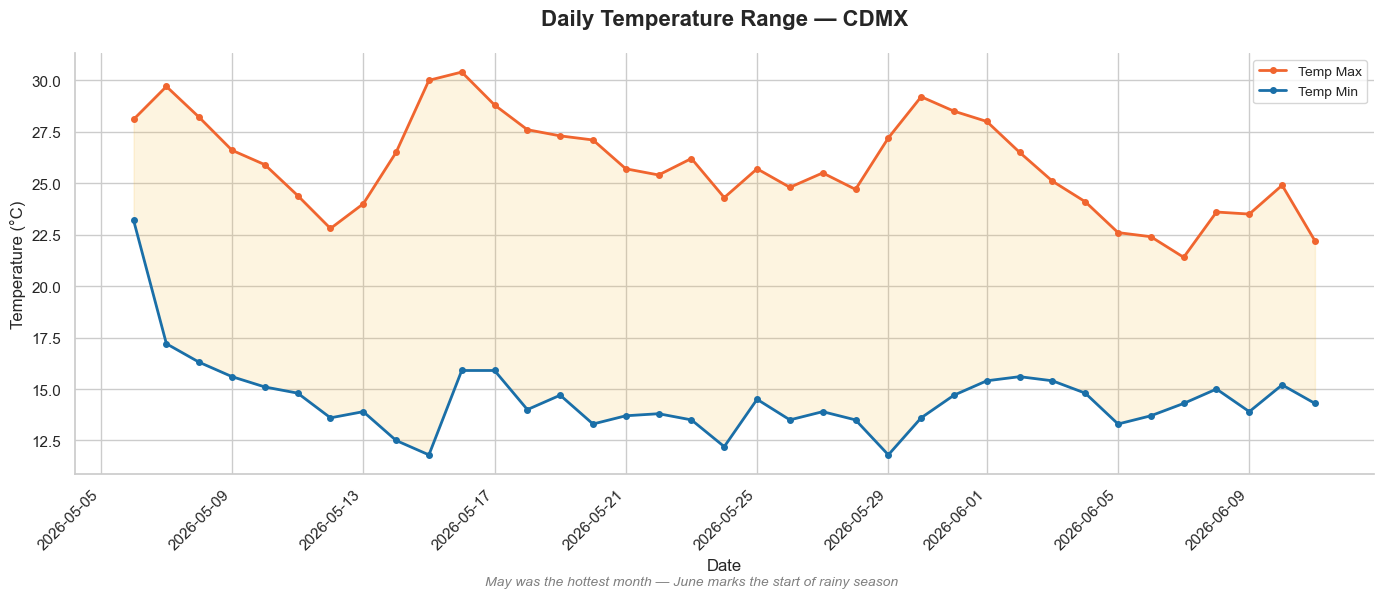

In [45]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df_wheather['date'], df_wheather['temp_max'],
        color=naranja, linewidth=2, marker='o', markersize=4,
        label='Temp Max')
ax.plot(df_wheather['date'], df_wheather['temp_min'],
        color=azul, linewidth=2, marker='o', markersize=4,
        label='Temp Min')
ax.fill_between(df_wheather['date'],
                df_wheather['temp_max'],
                df_wheather['temp_min'],
                alpha=0.15, color=amarillo)
ax.set_title('Daily Temperature Range — CDMX', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Temperature (°C)', fontsize=12)
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xticks(rotation=45, ha='right')
plt.figtext(0.5, 0.01, 'May was the hottest month — June marks the start of rainy season',
            ha='center', fontsize=10, style='italic', color='gray')
plt.tight_layout()
plt.savefig(r'C:\Users\PC\OneDrive\Documentos\Proyecto Ventas\visualizations\clima_temperatura.png',
            dpi=150, bbox_inches='tight')
plt.show()


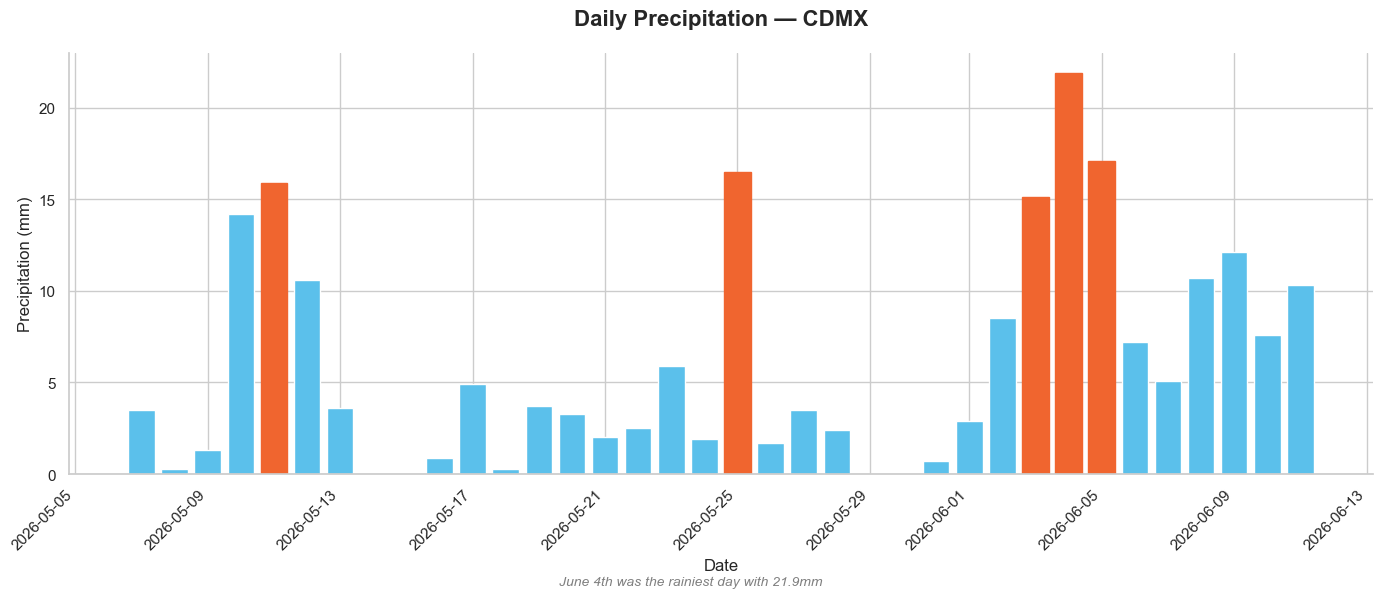

In [46]:
fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(df_wheather['date'], df_wheather['precipitation'],
              color=azul_claro, edgecolor='white', width=0.8)
top5_fechas = Q3['date'].values
for bar, fecha in zip(bars, df_wheather['date']):
    if str(fecha) in str(top5_fechas):
        bar.set_color(naranja)
ax.set_title('Daily Precipitation — CDMX', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Precipitation (mm)', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xticks(rotation=45, ha='right')
plt.figtext(0.5, 0.01, 'June 4th was the rainiest day with 21.9mm',
            ha='center', fontsize=10, style='italic', color='gray')
plt.tight_layout()
plt.savefig(r'C:\Users\PC\OneDrive\Documentos\Proyecto Ventas\visualizations\clima_precipitacion.png',
            dpi=150, bbox_inches='tight')
plt.show()

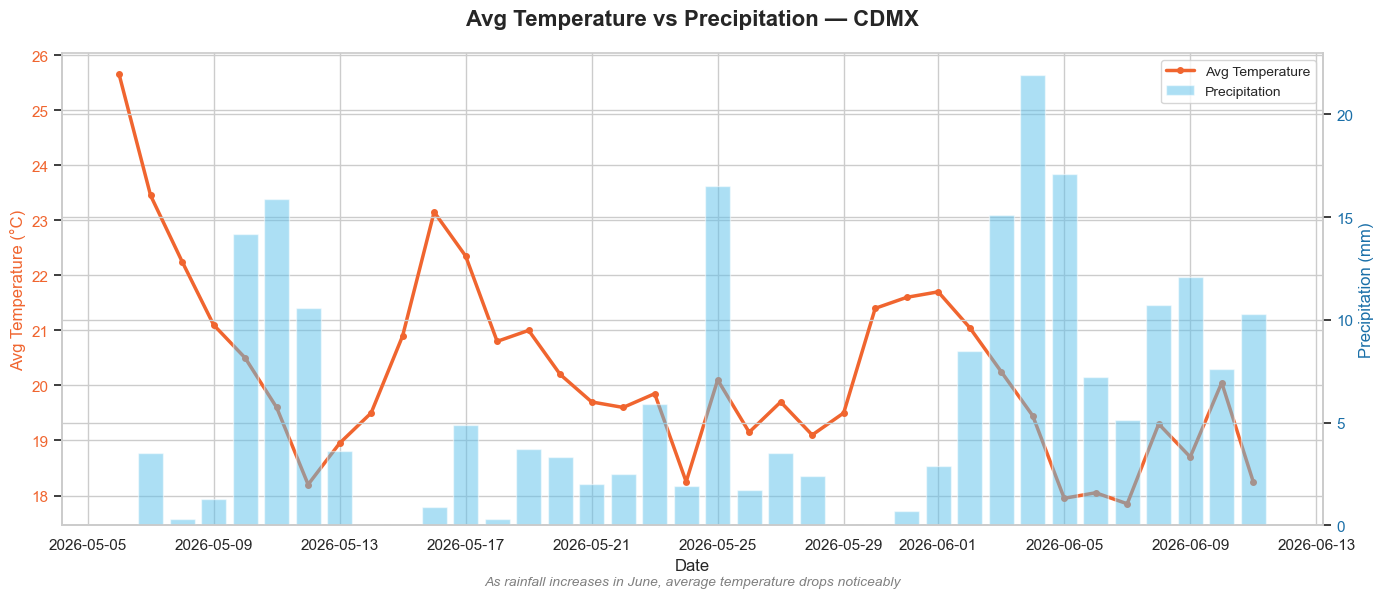

In [47]:
fig, ax1 = plt.subplots(figsize=(14, 6))
ax1.plot(df_wheather['date'], df_wheather['avg_temp'],
         color=naranja, linewidth=2.5, marker='o', markersize=4,
         label='Avg Temperature')
ax1.set_ylabel('Avg Temperature (°C)', fontsize=12, color=naranja)
ax1.tick_params(axis='y', labelcolor=naranja)
ax2 = ax1.twinx()
ax2.bar(df_wheather['date'], df_wheather['precipitation'],
        color=azul_claro, alpha=0.5, width=0.8, label='Precipitation')
ax2.set_ylabel('Precipitation (mm)', fontsize=12, color=azul)
ax2.tick_params(axis='y', labelcolor=azul)
ax1.set_title('Avg Temperature vs Precipitation — CDMX', fontsize=16, fontweight='bold', pad=20)
ax1.set_xlabel('Date', fontsize=12)
ax1.spines['top'].set_visible(False)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=10)
plt.xticks(rotation=45, ha='right')
plt.figtext(0.5, 0.01, 'As rainfall increases in June, average temperature drops noticeably',
            ha='center', fontsize=10, style='italic', color='gray')
plt.tight_layout()
plt.savefig(r'C:\Users\PC\OneDrive\Documentos\Proyecto Ventas\visualizations\clima_temp_vs_precipitacion.png',
            dpi=150, bbox_inches='tight')
plt.show()